# Global Natural Disaster Analysis
by: Samir Ahmadi


## Introduction

Natural disasters have a profound impact on societies worldwide, causing loss of life, significant economic damage, and widespread human suffering. In this project, we explore global disaster data sourced from the Emergency Events Database (EMDAT), which tracks various types of natural disasters, their frequency, and their effects. The data includes important metrics such as the number of affected people, fatalities, and the financial damages caused by these events.

Given the diverse nature of natural disasters, we are particularly interested in the relationships between disaster types and their corresponding impacts. Specifically, we aim to answer the following questions:

- **What disaster types have the highest total number of deaths, affected populations, and economic damages?**
- **How do disaster types compare in terms of the frequency and severity of their impacts?**
- **Which disaster types are more likely to cause widespread economic damage versus high human tolls?**
- **Are there trends over time in the number of disasters and their severity, and how do these trends vary by disaster type?**

To address these questions, we perform exploratory data analysis, aggregating and visualizing key statistics related to fatalities, affected populations, and financial damage by disaster type. The resulting visualizations will help us identify patterns, trends, and potential areas of focus for disaster preparedness and response strategies.

---

## Analysis

The analysis begins with importing the data and cleaning it, followed by calculating total impacts for each disaster type. Specifically, we will:

1. **Data Import and Cleaning**:
    - Import the dataset and inspect its structure.
    - Clean the dataset, removing any rows with missing or invalid values in the key columns (e.g., Total Deaths, Total Affected, and Total Damage).

2. **Exploratory Data Analysis**:
    - **Aggregation**: Group the data by `Disaster Type` and calculate the total number of deaths, affected people, and total damage for each disaster type.
    - **Data Visualization**: Use bar charts to visualize these total impacts by disaster type. We will also explore the relationship between disaster types and their severity across multiple factors.

3. **Graphical Representations**:
    - We will create grouped bar charts to show the total deaths, affected populations, and damages for each disaster type side-by-side, making it easy to compare the relative impacts.
    - Additionally, stacked bar charts will be created to visualize the cumulative impact of each disaster type, incorporating all three factors (deaths, affected populations, and damage).

These visualizations will answer key questions, including:
- **Which disaster types are most impactful in terms of fatalities, affected populations, and total damages?**
- **How do different disaster types compare in terms of their frequency and overall severity?**
- **What patterns emerge when we examine the relationship between disaster frequency and severity over time?**

In the following code, we will conduct these analyses step by step and generate the necessary plots to illustrate the findings.





![natural_disaster](https://curriculumcastle.com/wp-content/uploads/2021/10/natural-disasters-featured.jpg)
##### *Image source: https://curriculumcastle.com/wp-content/uploads/2021/10/natural-disasters-featured.jpg*

## Methods
### Data Collection

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display

In [4]:
# Load the dataset
natural_disaster = pd.read_csv('https://raw.githubusercontent.com/Sam-A28/compsci/refs/heads/main/_EmergencyEventsDatabase-CountryProfiles_emdat-country-profiles_2023_04_06%20(1).csv')

# Display dataframe
natural_disaster.head()


,Year,Country,ISO,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)",CPI
0,2010,Afghanistan,AFG,Natural,Geophysical,Earthquake,Ground movement,1,1070.0,11.0,NaN,NaN,"74,5094440781961"
1,2010,Afghanistan,AFG,Natural,Hydrological,Flood,Riverine flood,2,45000.0,135.0,NaN,NaN,"74,5094440781961"
2,2010,Afghanistan,AFG,Natural,Hydrological,Landslide,Avalanche,2,130.0,204.0,NaN,NaN,"74,5094440781961"
3,2010,Angola,AGO,Natural,Hydrological,Flood,Riverine flood,3,189781.0,25.0,NaN,NaN,"74,5094440781961"
4,2010,Albania,ALB,Natural,Hydrological,Flood,Riverine flood,1,14000.0,NaN,NaN,NaN,"74,5094440781961"


### Data Cleaning

The dataset contained many missing and inconsistent values so the following changes for data cleaning were implemented.

1. Dropping unnecessary columns (e.g., `Total Damage (USD, original)`, `CPI`, `ISO`).

In [5]:

# Cleaning data
# Drop unnecessary columns
natural_disaster.drop(columns=['ISO','CPI', 'Total Damage (USD, original)'], inplace=True)

2. Adjusting the values in following columns `Total Damage (USD, adjusted)` `Total Affected`,  and `Total Death` to 2 decimal places.

In [6]:
# Round 'Total Damage (USD, adjusted)' to 2 decimal places
natural_disaster['Total Damage (USD, adjusted)'] = natural_disaster['Total Damage (USD, adjusted)'].round(2)
natural_disaster['Total Affected'] = natural_disaster['Total Affected'].round(2)
natural_disaster['Total Deaths'] = natural_disaster['Total Deaths'].round(2)

#Changes United States of America to USA for better data visualizations
natural_disaster['Country'] = natural_disaster['Country'].replace('United States of America', 'USA')


3. Checking for rows with missing data and eliminating them. 

In [7]:
# Drop rows with missing values
natural_disaster.dropna(axis=0, inplace=True)

# Check for missing values
missing_data = natural_disaster.isnull().sum()
print("Missing values per column after cleaning:")
print(missing_data)

# Display the number of rows remaining after cleaning
print(f"Total sample size after cleaning: {natural_disaster.shape[0]} rows")

Missing values per column after cleaning:
Year                            0
Country                         0
Disaster Group                  0
Disaster Subgroup               0
Disaster Type                   0
Disaster Subtype                0
Total Events                    0
Total Affected                  0
Total Deaths                    0
Total Damage (USD, adjusted)    0
dtype: int64
Total sample size after cleaning: 646 rows


In [8]:
# Reset index after cleaning
natural_disaster.reset_index(drop=True, inplace=True)

# Display cleaned dataset info
natural_disaster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646 entries, 0 to 645
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          646 non-null    int64  
 1   Country                       646 non-null    object 
 2   Disaster Group                646 non-null    object 
 3   Disaster Subgroup             646 non-null    object 
 4   Disaster Type                 646 non-null    object 
 5   Disaster Subtype              646 non-null    object 
 6   Total Events                  646 non-null    int64  
 7   Total Affected                646 non-null    float64
 8   Total Deaths                  646 non-null    float64
 9   Total Damage (USD, adjusted)  646 non-null    float64
dtypes: float64(3), int64(2), object(5)
memory usage: 50.6+ KB



The total sample size after cleaning the dataset is 646 observations, representing the final dataset used for analysis.

## Exploratory Data Analysis
Understanding the relationships between different types of natural disasters and their impacts concerning: Country, Year, Event Total, Total Affected, Total Deaths, Total Damaged (Based in USD and adjusted to current standards). These relationships will be explored through statistical summaries and visualizations (e.g. Graphs).

### Distribution of Disaster Types
The analysis will examine the distributions of disaster types summarises the most frequent to the least frequent type of natural disaster.

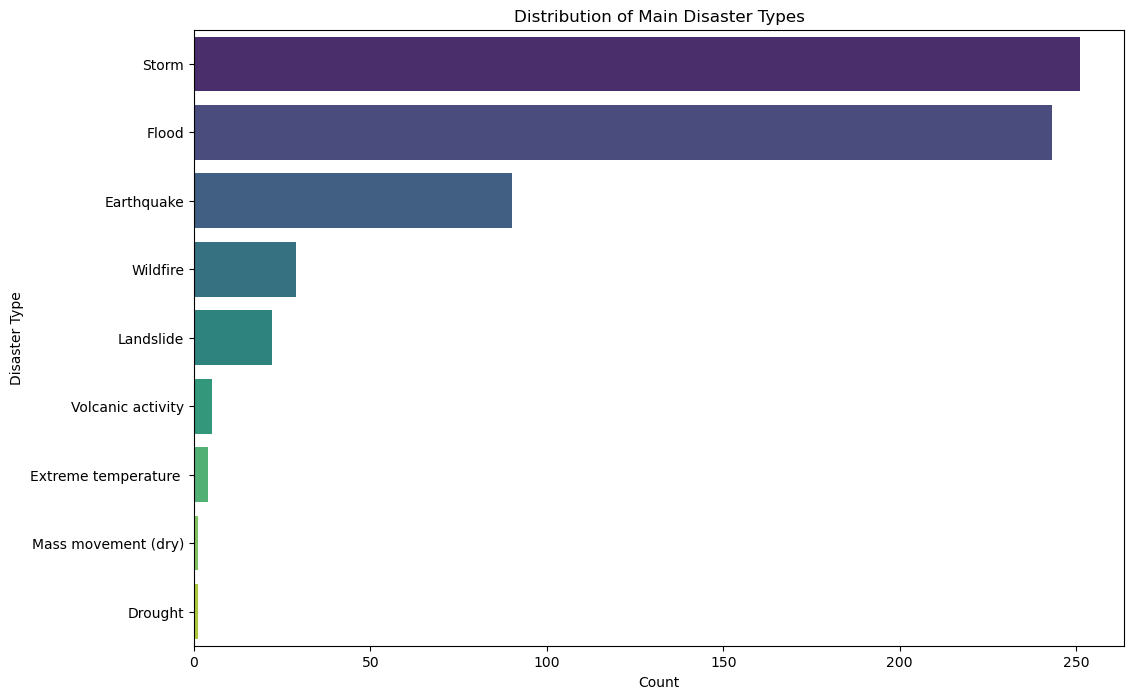

The most frequently occurring disaster type is 'Storm' with 251 occurrences.


In [9]:
# Group by disaster type and count occurrences
disaster_counts_main = natural_disaster['Disaster Type'].value_counts()

# Identify the most frequently occurring main disaster type
most_frequent_disaster_main = disaster_counts_main.idxmax()
most_frequent_count_main = disaster_counts_main.max()

# Plot the distribution of main disaster types
plt.figure(figsize=(12, 8))
sns.barplot(y=disaster_counts_main.index, x=disaster_counts_main.values, palette='viridis')

# Add a title and axis labels
plt.title('Distribution of Main Disaster Types')
plt.xlabel('Count')
plt.ylabel('Disaster Type')

# Display the plot
plt.show()

# Print the most frequent main disaster type
print(f"The most frequently occurring disaster type is '{most_frequent_disaster_main}' with {most_frequent_count_main} occurrences.")

### Most Common Disaster Subtypes

While disaster types provide a broad classification, disaster subtypes offer a more detailed view of specific events. This analysis identifies the most frequently occurring subtypes within the dataset, helping to reveal the particular hazards that drive overall disaster statistics. Examining subtypes allows for a deeper understanding of the nature and characteristics of disaster occurrences worldwide.

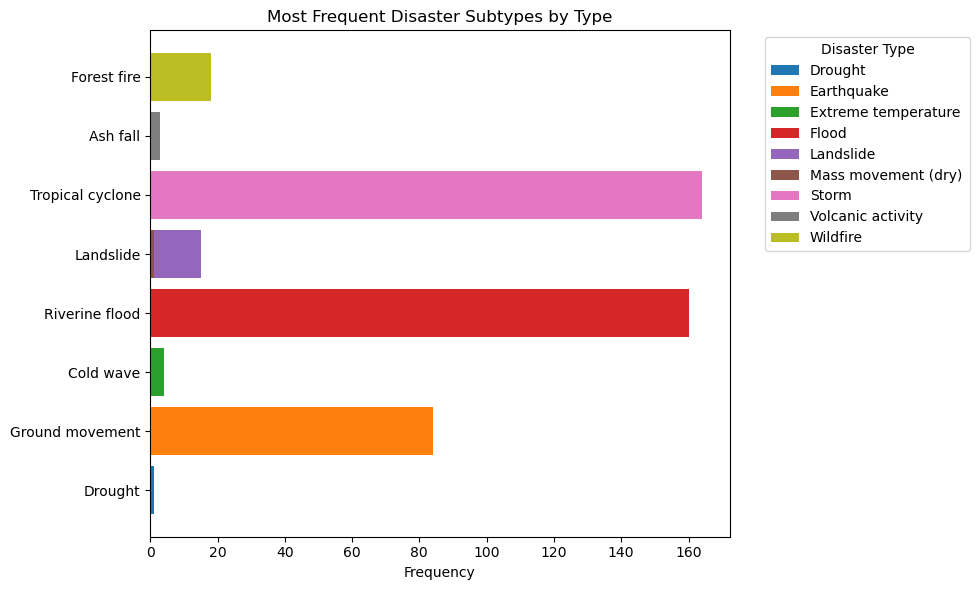


Most Frequent Disaster Subtypes by Type:
           Disaster Type  Disaster Subtype  Count
0                Drought           Drought      1
1             Earthquake   Ground movement     84
3   Extreme temperature          Cold wave      4
5                  Flood    Riverine flood    160
7              Landslide         Landslide     15
9    Mass movement (dry)         Landslide      1
12                 Storm  Tropical cyclone    164
13     Volcanic activity          Ash fall      3
16              Wildfire       Forest fire     18


In [10]:
most_frequent_subtype = natural_disaster.groupby(['Disaster Type', 'Disaster Subtype']).size().reset_index(name='Count')
most_frequent_subtype = most_frequent_subtype.loc[most_frequent_subtype.groupby('Disaster Type')['Count'].idxmax()]

# Plot the relationship between disaster type and the most frequent disaster subtype
plt.figure(figsize=(10, 6))
for disaster_type in most_frequent_subtype['Disaster Type'].unique():
    subtype_data = most_frequent_subtype[most_frequent_subtype['Disaster Type'] == disaster_type]
    plt.barh(subtype_data['Disaster Subtype'], subtype_data['Count'], label=disaster_type)

plt.xlabel('Frequency')
plt.title('Most Frequent Disaster Subtypes by Type')
plt.legend(title="Disaster Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print the most frequent subtypes summary
print("\nMost Frequent Disaster Subtypes by Type:")
print(most_frequent_subtype)



## Total Affected Population by Year / Total Deaths by Year

The following visualization explores how the number of people affected by natural disasters has changed over time. Analyzing trends in affected populations helps identify years with particularly severe disasters and highlights fluctuations in disaster impacts. These patterns can provide insight into changing environmental conditions, population growth, and disaster preparedness efforts.

This second graph illustrates the total number of disaster-related deaths recorded each year. Fatality trends provide an important measure of disaster severity and help identify years in which particularly catastrophic events occurred. Comparing annual death totals can also reveal improvements or challenges in disaster response and mitigation efforts over time.

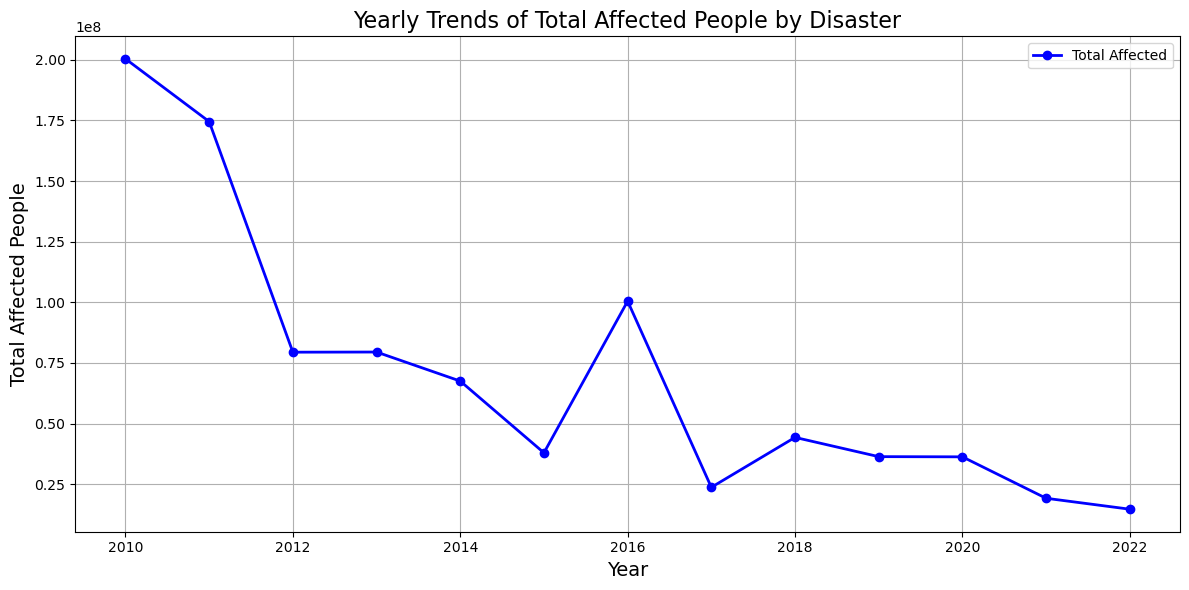

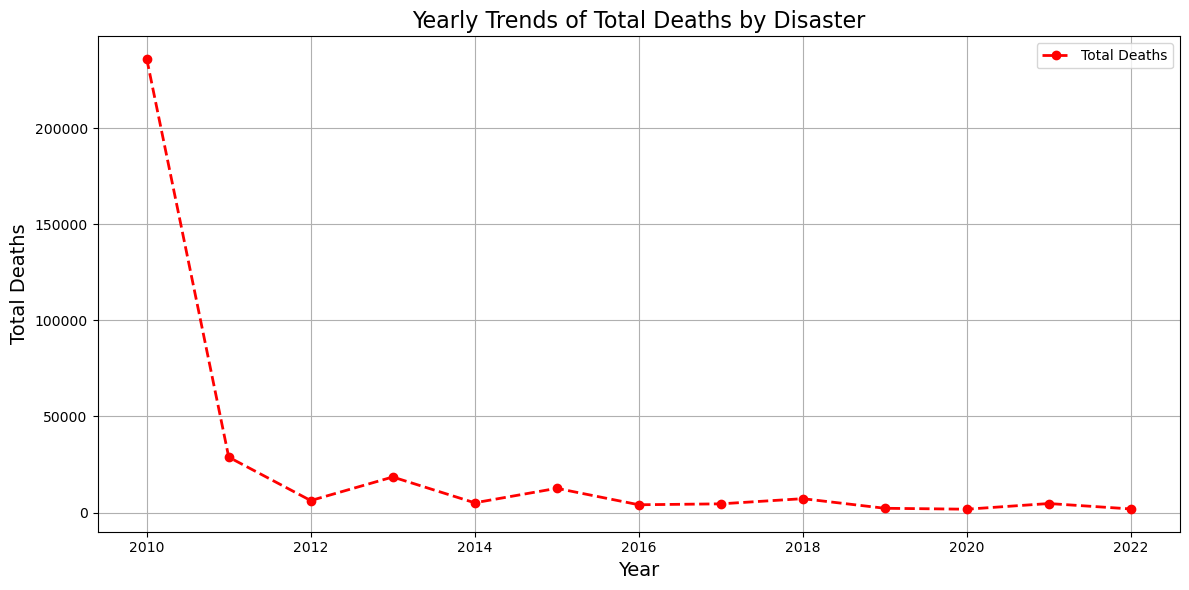

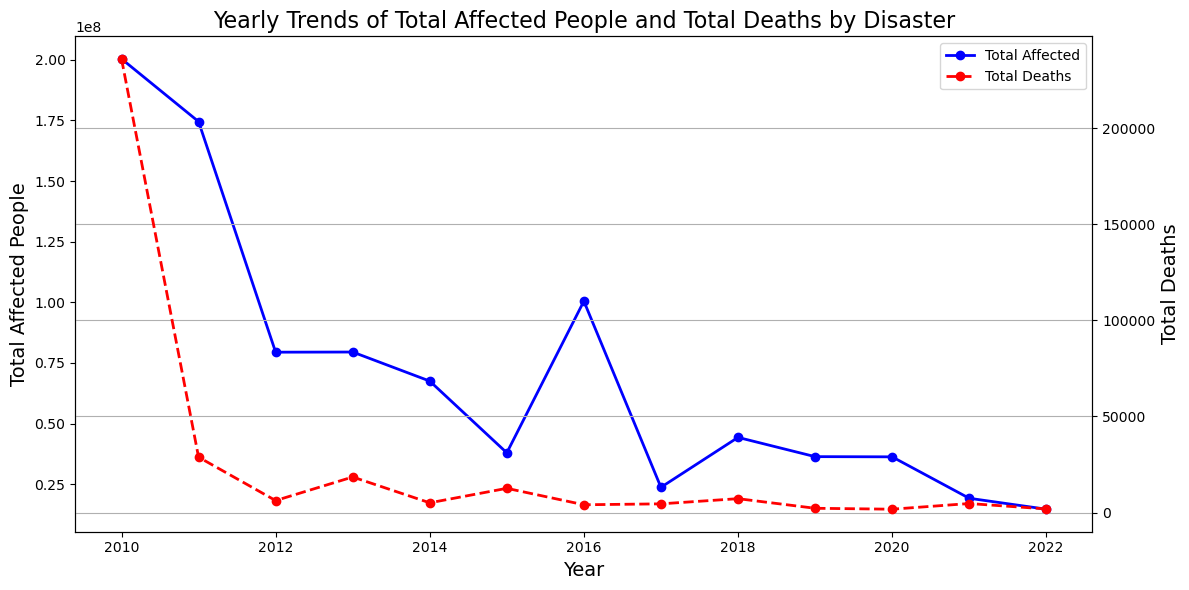

Summary Statistics of Yearly Trends:

Year with the most Total Deaths: 2010 with 235,985.0 deaths
Year with the most Total Affected: 2010 with 200,387,713.0 affected people
Year with the minimum Total Deaths: 2020 with 1,715.0 deaths
Year with the minimum Total Affected: 2022 with 14,725,054.0 affected people


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Group the dataset by 'Year' and calculate the total for key metrics (affected and deaths)
time_trends = natural_disaster.groupby('Year')[['Total Affected', 'Total Deaths']].sum()

# Create the first plot for Total Affected over time
plt.figure(figsize=(12, 6))
plt.plot(time_trends.index, time_trends['Total Affected'], label='Total Affected', marker='o', linestyle='-', color='blue', linewidth=2)
plt.title('Yearly Trends of Total Affected People by Disaster', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Affected People', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Create the second plot for Total Deaths over time
plt.figure(figsize=(12, 6))
plt.plot(time_trends.index, time_trends['Total Deaths'], label='Total Deaths', marker='o', linestyle='--', color='red', linewidth=2)
plt.title('Yearly Trends of Total Deaths by Disaster', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Deaths', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Overlapping graph
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Total Affected
ax1.plot(
    time_trends.index,
    time_trends['Total Affected'],
    label='Total Affected',
    marker='o',
    linestyle='-',
    color='blue',
    linewidth=2
)

ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Total Affected People', fontsize=14)

# Create second axis
ax2 = ax1.twinx()

# Plot Total Deaths
ax2.plot(
    time_trends.index,
    time_trends['Total Deaths'],
    label='Total Deaths',
    marker='o',
    linestyle='--',
    color='red',
    linewidth=2
)

ax2.set_ylabel('Total Deaths', fontsize=14)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title('Yearly Trends of Total Affected People and Total Deaths by Disaster', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print summary statistics for affected people and deaths over time
print("Summary Statistics of Yearly Trends:")

# Year with the most total deaths
max_deaths_year = time_trends['Total Deaths'].idxmax()
max_deaths_value = time_trends['Total Deaths'].max()

# Year with the most total affected
max_affected_year = time_trends['Total Affected'].idxmax()
max_affected_value = time_trends['Total Affected'].max()

# Year with the minimum total deaths
min_deaths_year = time_trends['Total Deaths'].idxmin()
min_deaths_value = time_trends['Total Deaths'].min()

# Year with the minimum total affected
min_affected_year = time_trends['Total Affected'].idxmin()
min_affected_value = time_trends['Total Affected'].min()

# Print results
print(f"\nYear with the most Total Deaths: {max_deaths_year} with {max_deaths_value:,} deaths")
print(f"Year with the most Total Affected: {max_affected_year} with {max_affected_value:,} affected people")
print(f"Year with the minimum Total Deaths: {min_deaths_year} with {min_deaths_value:,} deaths")
print(f"Year with the minimum Total Affected: {min_affected_year} with {min_affected_value:,} affected people")



### Countries with the Highest Number of Disaster-Related Deaths and Injuries

This analysis focuses on the countries that recorded the highest numbers of disaster-related fatalities and injuries. Comparing death and injury totals across countries provides insight into the human cost of disasters and may reflect differences in exposure, infrastructure quality, emergency response capabilities, and disaster preparedness measures.

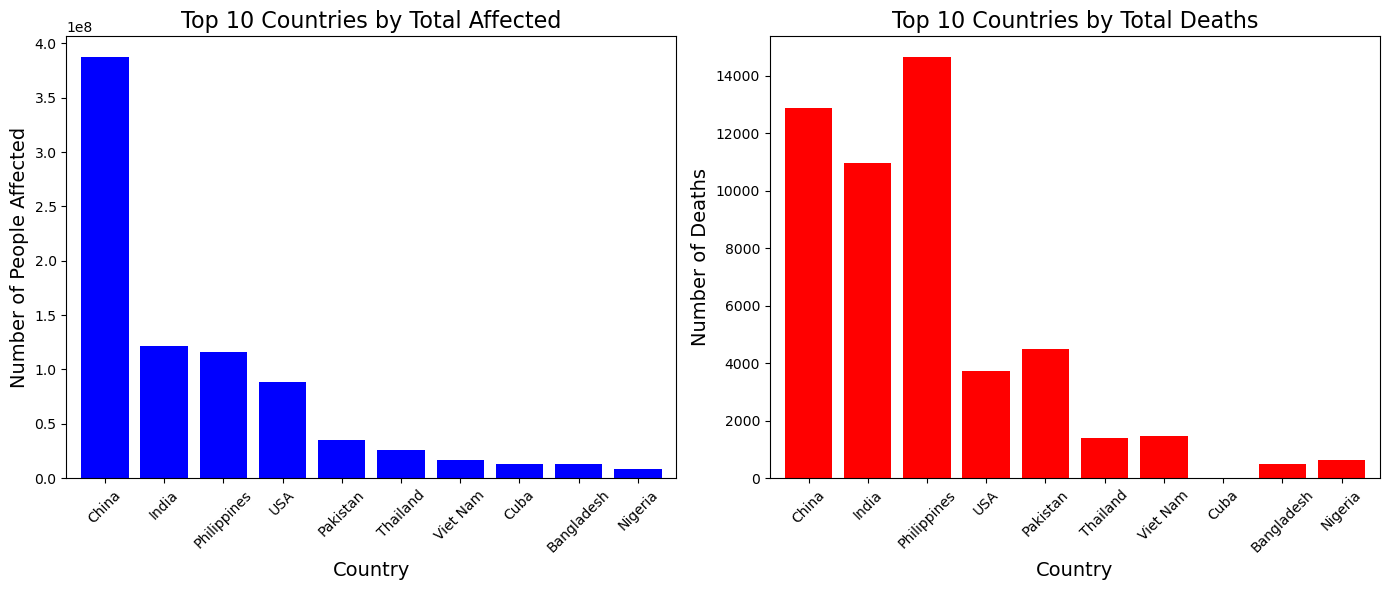

Top 10 Most Affected Countries:
             Total Affected  Total Deaths
Country                                  
China           387159927.0       12880.0
India           121714649.0       10966.0
Philippines     116008472.0       14633.0
USA              88619598.0        3724.0
Pakistan         35217188.0        4503.0
Thailand         25806487.0        1399.0
Viet Nam         16938808.0        1467.0
Cuba             13206780.0          16.0
Bangladesh       12871267.0         479.0
Nigeria           8647402.0         645.0


In [12]:
# Country-Specific Analysis: Identifying the countries most impacted by disasters

natural_disaster['Country'] = natural_disaster['Country'].replace({
    'United States of America (the)': 'USA',
    'Philippines (the)': 'Philippines'
})

# Group the dataset by 'Country' and calculate the total for relevant metrics
country_impact = natural_disaster.groupby('Country')[['Total Affected', 'Total Deaths']].sum()

# Sort countries by total affected and select the top 10
top_countries = country_impact.sort_values('Total Affected', ascending=False).head(10)

# Create a figure with two subplots (one for Total Affected, one for Total Deaths)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Create 1 row and 2 columns of plots

# Plot Total Affected for the top 10 countries
top_countries['Total Affected'].plot(kind='bar', ax=axes[0], color='blue', width=0.8)
axes[0].set_title('Top 10 Countries by Total Affected', fontsize=16)
axes[0].set_xlabel('Country', fontsize=14)
axes[0].set_ylabel('Number of People Affected', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Plot Total Deaths for the top 10 countries
top_countries['Total Deaths'].plot(kind='bar', ax=axes[1], color='red', width=0.8)
axes[1].set_title('Top 10 Countries by Total Deaths', fontsize=16)
axes[1].set_xlabel('Country', fontsize=14)
axes[1].set_ylabel('Number of Deaths', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout to avoid clipping of x-axis labels
plt.tight_layout()

# Display the plots
plt.show()

# Print the top 10 countries and their total affected and deaths
print("Top 10 Most Affected Countries:")
print(top_countries)

### Comparison of Affected Populations Across Disaster Types and Years

This stacked visualization compares the number of individuals affected by different disaster types over multiple years. By examining both the magnitude and composition of impacts, it becomes possible to identify which disasters contribute most significantly to human suffering and how those contributions change over time.

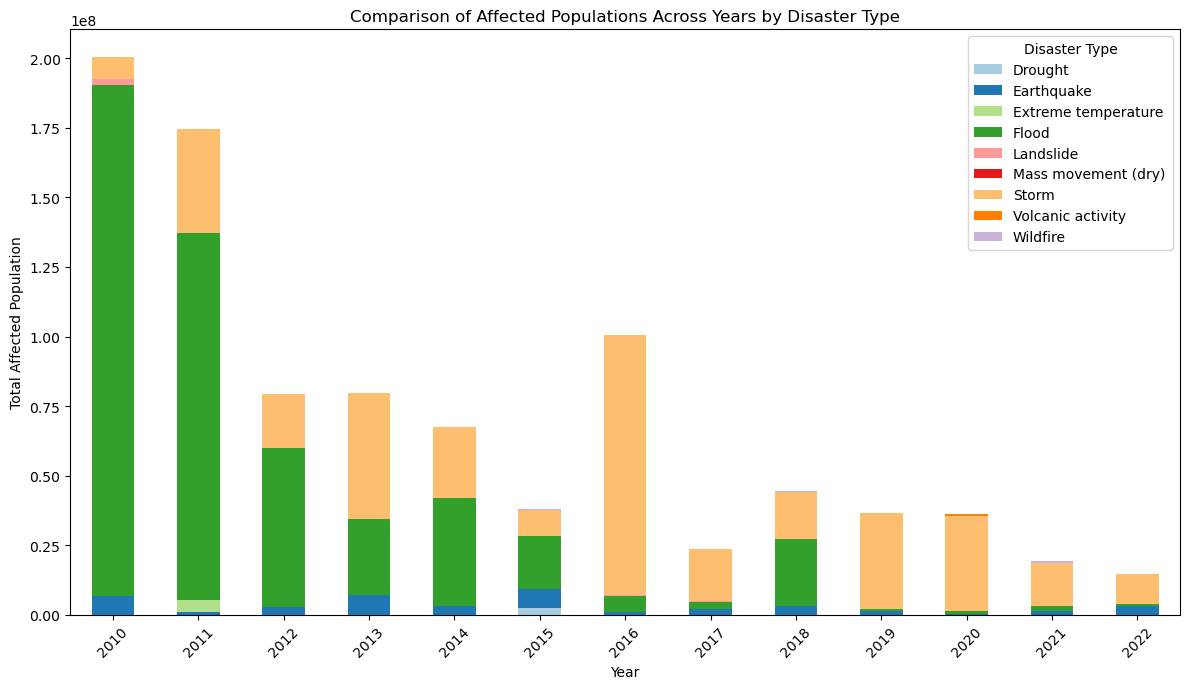

In [14]:
# 3. Comparison of Affected Populations Across Years using Stacked Bar Chart
# Aggregating total affected populations by year and disaster type
affected_year = natural_disaster.groupby(['Year', 'Disaster Type'])['Total Affected'].sum().unstack().fillna(0)

# Plotting the stacked bar chart (Fixed the variable name in len())
affected_year.plot(kind='bar', stacked=True, figsize=(12, 7), color=plt.cm.Paired.colors[:len(affected_year.columns)])
plt.title('Comparison of Affected Populations Across Years by Disaster Type')
plt.xlabel('Year')
plt.ylabel('Total Affected Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Comparing Deaths, Affected Population, and Economic Damage by Disaster Type

Natural disasters can impact societies in multiple ways. This final comparison examines three important measures of disaster severity: fatalities, affected populations, and economic losses. Evaluating these metrics together provides a more comprehensive understanding of disaster impacts and demonstrates that the most economically damaging disasters are not always the deadliest or those affecting the largest populations.


Total Impact of Disasters by Type (Deaths, Affected People, Total Damage):
          Disaster Type  Total Deaths  Total Affected  \
0               Drought          24.0       2520000.0   
1            Earthquake      269357.0      39538459.0   
2  Extreme temperature           68.0       4379092.0   
3                 Flood       31069.0     494715513.0   
4             Landslide        4974.0       2629312.0   
5   Mass movement (dry)          46.0             2.0   
6                 Storm       27020.0     368559138.0   
7     Volcanic activity         116.0        954018.0   
8              Wildfire         561.0       1354384.0   

   Total Damage (USD, adjusted)  
0                  7.408452e+07  
1                  5.082116e+11  
2                  1.132338e+09  
3                  3.493187e+11  
4                  4.818299e+09  
5                  1.005009e+07  
6                  1.234763e+12  
7                  1.524194e+09  
8                  6.188537e+10  


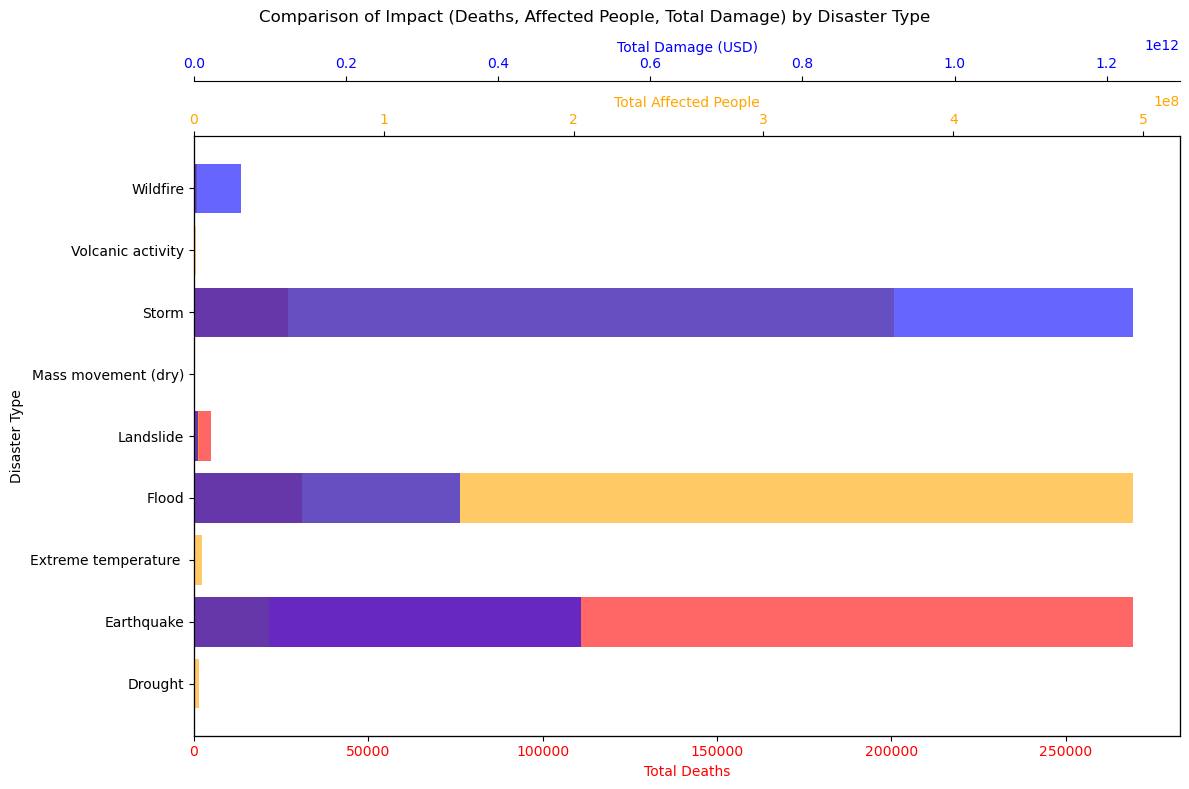

In [ ]:
# Calculate total impact factors (deaths, affected people, and total damage) for each disaster type
impact_data = natural_disaster.groupby('Disaster Type').agg({
    'Total Deaths': 'sum',
    'Total Affected': 'sum',
    'Total Damage (USD, adjusted)': 'sum'
}).reset_index()

# Print the total impact summary
print("\nTotal Impact of Disasters by Type (Deaths, Affected People, Total Damage):")
print(impact_data)

# Plot the comparison of impacts (deaths, affected people, and damage)
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot total deaths
ax1.barh(impact_data['Disaster Type'], impact_data['Total Deaths'], color='red', alpha=0.6, label='Total Deaths')
ax1.set_xlabel('Total Deaths', color='red')
ax1.set_ylabel('Disaster Type')
ax1.tick_params(axis='x', labelcolor='red')

# Create a second x-axis for affected people and total damage
ax2 = ax1.twiny()
ax2.barh(impact_data['Disaster Type'], impact_data['Total Affected'], color='orange', alpha=0.6, label='Total Affected')
ax2.set_xlabel('Total Affected People', color='orange')
ax2.tick_params(axis='x', labelcolor='orange')

ax3 = ax1.twiny()
ax3.spines['top'].set_position(('outward', 40))
ax3.barh(impact_data['Disaster Type'], impact_data['Total Damage (USD, adjusted)'], color='blue', alpha=0.6, label='Total Damage (USD)')
ax3.set_xlabel('Total Damage (USD)', color='blue')
ax3.tick_params(axis='x', labelcolor='blue')

# Add legends and titles
fig.suptitle('Comparison of Impact (Deaths, Affected People, Total Damage) by Disaster Type')
fig.tight_layout()

plt.show()


## Discussion ##
This project analyzed global natural disaster data from the Emergency Events Database (EMDAT) to identify trends in disaster frequency, human impact, and economic losses. Through data cleaning and exploratory data analysis, several patterns emerged regarding the occurrence and severity of natural disasters worldwide. The analysis revealed that weather-related disasters, including floods and storms, are among the most frequently recorded events. Visualizations of disaster types and subtypes provided insight into which disasters contribute most significantly to global disaster activity and how their occurrence varies across regions and years.

The results also demonstrated substantial differences in the impact of disasters over time and across countries. Some countries experienced significantly higher numbers of affected individuals and fatalities, likely due to factors such as geographic location, population density, infrastructure, and disaster preparedness. Trend analysis showed that disaster impacts fluctuate considerably from year to year, with certain events causing large spikes in deaths, affected populations, or economic damage. These findings emphasize the importance of examining multiple impact measures rather than relying on a single indicator when evaluating disaster severity.

Overall, the project highlights the widespread and diverse effects of natural disasters on societies around the world. While some disasters result in high mortality rates, others primarily cause economic disruption or affect large populations without producing substantial fatalities. Understanding these patterns can help governments, organizations, and researchers develop more effective disaster mitigation strategies, allocate resources more efficiently, and improve preparedness efforts aimed at reducing future losses.

# Limitations #

Several limitations should be acknowledged:

 - Missing values were removed during data cleaning, which reduced the sample size and may have excluded some relevant observations.
 - The dataset only includes recorded events within the EMDAT database and may not capture every disaster occurrence worldwide.
 - Economic damage estimates are subject to reporting differences between countries and organizations.
 - The analysis focused primarily on descriptive statistics and visualization rather than predictive modeling or causal analysis.


## References

1. Emergency Events Database (EMDAT). (2024). *EMDAT Country Profiles Dataset*. Centre for Research on the Epidemiology of Disasters (CRED), Université catholique de Louvain.

   Website: https://www.emdat.be

2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.

3. Pandas Development Team. (2024). *Pandas Documentation*.

   Website: https://pandas.pydata.org/docs/

4. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90–95.

   Website: https://matplotlib.org/stable/index.html

5. Waskom, M. L. (2024). *Seaborn: Statistical Data Visualization*.

   Website: https://seaborn.pydata.org/

6. United Nations Office for Disaster Risk Reduction (UNDRR). (2024). *Disaster Risk Reduction Resources*.

   Website: https://www.undrr.org